In [120]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import data


plt.gray()

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'Right Image')

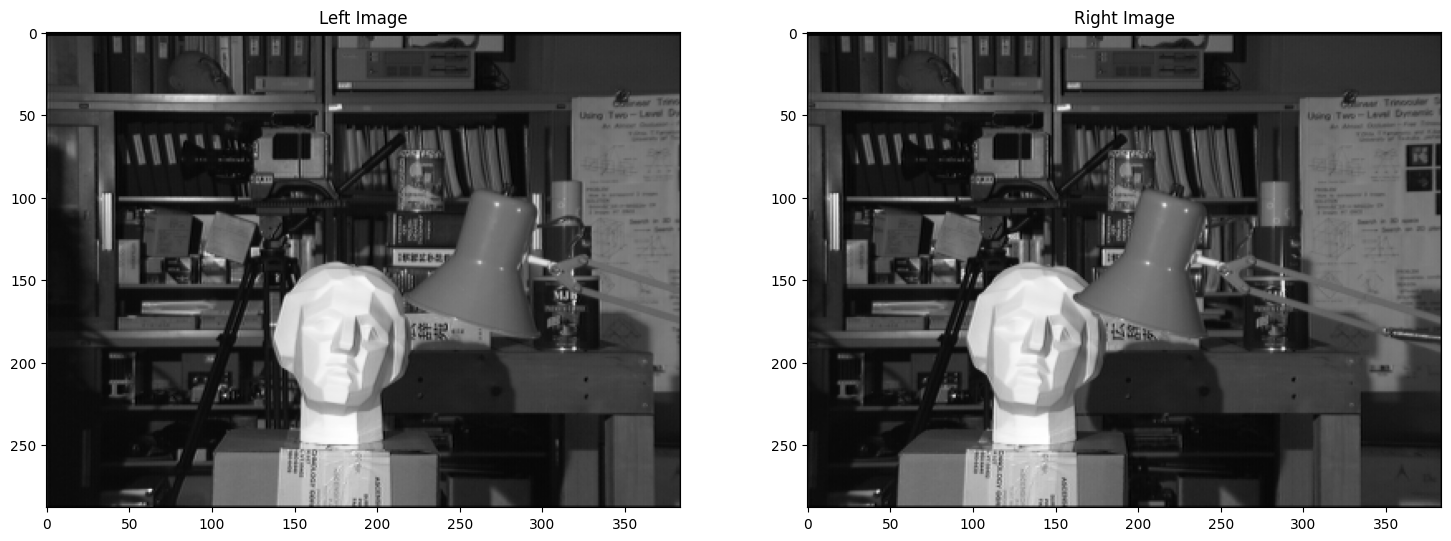

In [121]:
img_left = cv2.imread('tsukuba_left.png')
img_right = cv2.imread('tsukuba_right.png')

gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

f,(ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(gray_left)
ax_left.set_title('Left Image')
ax_right.imshow(gray_right)
ax_right.set_title('Right Image')

## Intermediate step 1

In [122]:
def sad(patch_a, patch_b):
    a = patch_a.astype(np.int16)
    b = patch_b.astype(np.int16)
    return np.sum(np.abs(a - b))

## Intermediate step 2

Minimum SAD is 119 for image 2


Text(0.5, 1.0, 'Right Image 2')

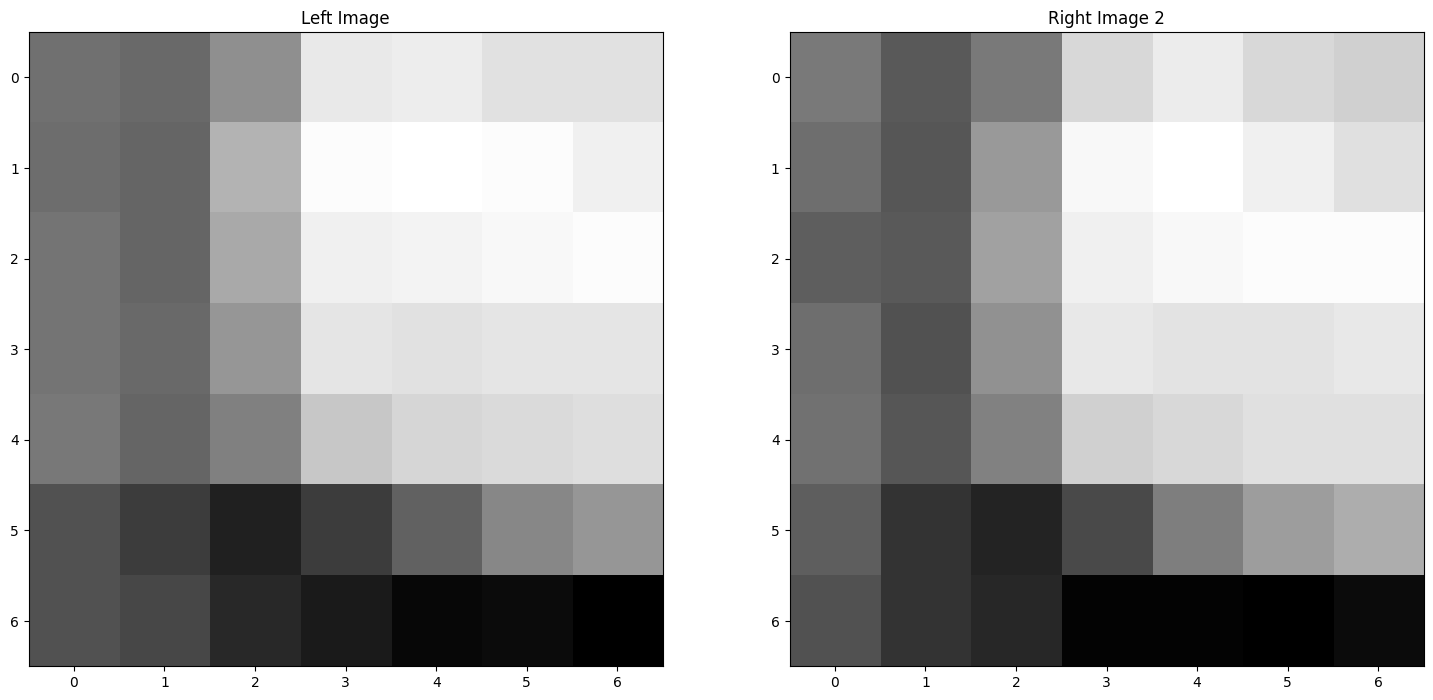

In [123]:
img_nose_1 = cv2.imread('nose1.png')
img_nose_1 = cv2.cvtColor(img_nose_1, cv2.COLOR_BGR2GRAY)
img_nose_2 = cv2.imread('nose2.png')
img_nose_2 = cv2.cvtColor(img_nose_2, cv2.COLOR_BGR2GRAY)
img_nose_3 = cv2.imread('nose3.png')
img_nose_3 = cv2.cvtColor(img_nose_3, cv2.COLOR_BGR2GRAY)
img_nose_left = cv2.imread('nose_left.png')
img_nose_left = cv2.cvtColor(img_nose_left, cv2.COLOR_BGR2GRAY)

sads = []
for img in [img_nose_1, img_nose_2, img_nose_3]:
    sads.append(sad(img_nose_left, img))
    
mini = np.argmin(sads)
print(f'Minimum SAD is {sads[mini]} for image {mini+1}')

f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))

ax_left.imshow(img_nose_left)
ax_left.set_title('Left Image')
ax_right.imshow([img_nose_1, img_nose_2, img_nose_3][mini])
ax_right.set_title(f'Right Image {mini+1}')

## Intermediate step 3

Min SAD is 119 at place [132, 0]


Text(0.5, 1.0, 'Nose Span Image')

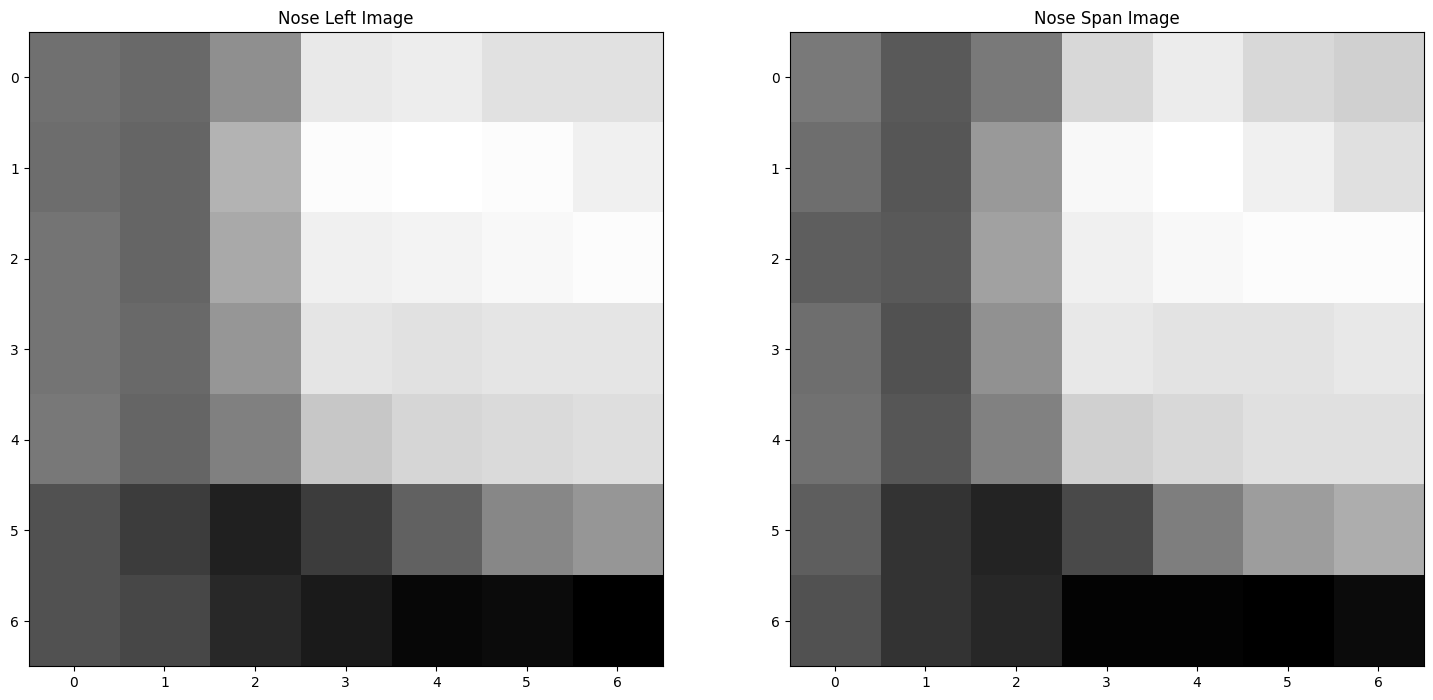

In [124]:
img_span = cv2.imread('nose_span.png')
img_span = cv2.cvtColor(img_span, cv2.COLOR_BGR2GRAY)
img_nose_left = cv2.imread('nose_left.png')
img_nose_left = cv2.cvtColor(img_nose_left, cv2.COLOR_BGR2GRAY)

sads = []

def sad_row(patch, row, y = 0):
    sads = []
    h, w = row.shape
    for x in range(w - 7 + 1):
        patch_span = row[0:7, x:x+7]
        place = [x, y]
        sads.append((place, sad(patch, patch_span)))
        
    return min(sads, key=lambda x: x[1])

mini = sad_row(img_nose_left, img_span)
print(f'Min SAD is {mini[1]} at place {mini[0]}')

f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(img_nose_left)
ax_left.set_title('Nose Left Image')
ax_right.imshow(img_span[mini[0][1]:mini[0][1]+7, mini[0][0]:mini[0][0]+7])
ax_right.set_title('Nose Span Image')


# The challenge

finished row 0 of 282
finished row 10 of 282
finished row 20 of 282
finished row 30 of 282
finished row 40 of 282
finished row 50 of 282
finished row 60 of 282
finished row 70 of 282
finished row 80 of 282
finished row 90 of 282
finished row 100 of 282
finished row 110 of 282
finished row 120 of 282
finished row 130 of 282
finished row 140 of 282
finished row 150 of 282
finished row 160 of 282
finished row 170 of 282
finished row 180 of 282
finished row 190 of 282
finished row 200 of 282
finished row 210 of 282
finished row 220 of 282
finished row 230 of 282
finished row 240 of 282
finished row 250 of 282
finished row 260 of 282
finished row 270 of 282
finished row 280 of 282


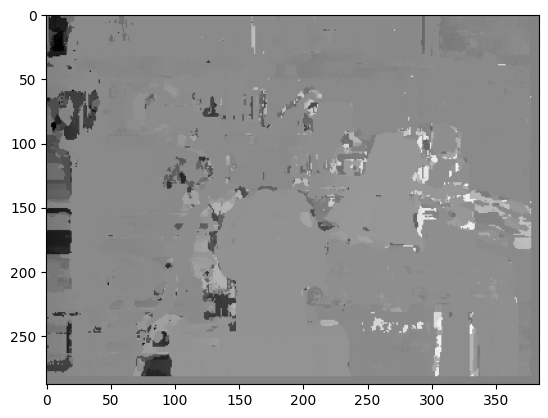

In [125]:
ts_left = cv2.imread('tsukuba_left.png')
ts_left = cv2.cvtColor(ts_left, cv2.COLOR_BGR2GRAY)

ts_right = cv2.imread('tsukuba_right.png')
ts_right = cv2.cvtColor(ts_right, cv2.COLOR_BGR2GRAY)

# create a disparity map
def disparity_map(ts_left, ts_right):
    h, w = ts_left.shape
    disparity_map = np.zeros((h, w), dtype=np.float32)
    for y in range(h - 7 + 1):
        row_left = ts_left[y:y+7, :]
        row_right = ts_right[y:y+7, :]
        for x in range(w - 7 + 1):
            patch_left = row_left[:, x:x+7]
            mini = sad_row(patch_left, row_right, y)
            disparity_map[y, x] = x - mini[0][0]

        if y % 10 == 0:
            print(f'finished row {y} of {h - 7 + 1}')
    
    return disparity_map

disparity_map = disparity_map(ts_left, ts_right)

plt.imshow(disparity_map, cmap='gray')


In [126]:
def export_pointcloud(disparity_map, colors):
    ply_header = '''ply
format ascii 1.0
element vertex %(vert_num)d
property float x
property float y
property float z
property uchar red
property uchar green
property uchar blue
end_header
'''

    def write_ply(fn, verts, colors):
        verts = verts.reshape(-1, 3)
        colors = colors.reshape(-1, 3)
        verts = np.hstack([verts, colors])
        with open(fn, 'wb') as f:
            f.write((ply_header % dict(vert_num=len(verts))).encode('utf-8'))
            np.savetxt(f, verts, fmt='%f %f %f %d %d %d')

    h, w = disparity_map.shape[:2]
    f = .8 * w  # guess for focal length. If you 3D reconstruction looks skewed in the viewing direction, try adjusting this parameter.
    Q = np.float32([[1, 0, 0, -0.5 * w],
                    [0, -1, 0, 0.5 * h],  # turn points 180 deg around x-axis,
                    [0, 0, 0, -f],  # so that y-axis looks up
                    [0, 0, 1, 0]])
    points = cv2.reprojectImageTo3D(disparity_map, Q)

    mask = disparity_map > disparity_map.min()
    out_points = points[mask]
    out_colors = colors[mask]
    out_fn = 'out.ply'
    write_ply(out_fn, out_points, out_colors)
    print(f'{out_fn} saved')

export_pointcloud(disparity_map=disparity_map, colors=img_left)

out.ply saved


finished row 0 of 282
finished row 10 of 282
finished row 20 of 282
finished row 30 of 282
finished row 40 of 282
finished row 50 of 282
finished row 60 of 282
finished row 70 of 282
finished row 80 of 282
finished row 90 of 282
finished row 100 of 282
finished row 110 of 282
finished row 120 of 282
finished row 130 of 282
finished row 140 of 282
finished row 150 of 282
finished row 160 of 282
finished row 170 of 282
finished row 180 of 282
finished row 190 of 282
finished row 200 of 282
finished row 210 of 282
finished row 220 of 282
finished row 230 of 282
finished row 240 of 282
finished row 250 of 282
finished row 260 of 282
finished row 270 of 282
finished row 280 of 282


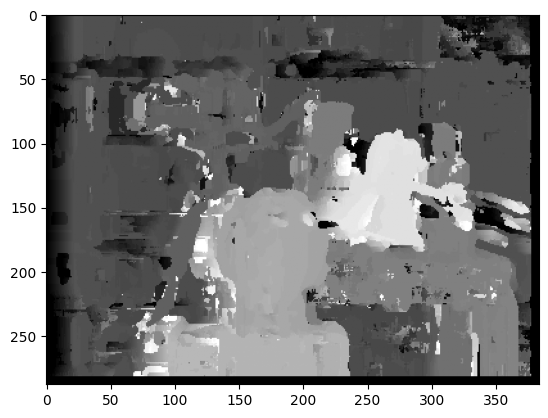

In [ ]:
def compute_disparity_map(ts_left, ts_right, patch=7, max_disparity=64):
    h, w = ts_left.shape
    n = w - patch + 1
    disparity_map = np.zeros((h, w), dtype=np.float32)

    for y in range(h - patch + 1):
        row_left = ts_left[y:y+patch, :].astype(np.int16)
        row_right = ts_right[y:y+patch, :].astype(np.int16)

        windows_left = np.lib.stride_tricks.sliding_window_view(row_left, (patch, patch))[0]
        windows_right = np.lib.stride_tricks.sliding_window_view(row_right, (patch, patch))[0]

        for xl in range(n):
            xr_lo = max(0, xl - max_disparity)
            xr_hi = xl + 1  # right image point is to the left of or at xl for this convention
            candidates = windows_right[xr_lo:xr_hi]
            costs = np.abs(candidates.astype(np.int16) - windows_left[xl]).sum(axis=(1, 2))
            best_j = np.argmin(costs)
            disparity_map[y, xl] = xl - (xr_lo + best_j)  # true disparity

        if y % 10 == 0:
            print(f'finished row {y} of {h - patch + 1}')

    return disparity_map
disparity_map = compute_disparity_map(ts_left, ts_right)
plt.imshow(disparity_map, cmap='gray')